# Helmholtz GMRES: Comparing Right-Hand Sides (RHS)

We solve the discrete Helmholtz problem
\[
(\Delta + k^2) u = f
\]
on a structured grid for several choices of \(f\) (the **right-hand side**):

- **Point source** (impulse-like load)  
- **Plane wave** (complex-valued forcing)  
- **Random Gaussian** (stress test for convergence)

For each case we report GMRES convergence via the relative residual
$\frac{\lVert r_m \rVert_2}{\lVert b \rVert_2},$
and visualize the resulting field \(u\) where feasible (1D/2D).  


In [1]:
# 03 — Right-hand sides: setup & imports

%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt

# Core API (same style as 02)
from src import GridSpec, GMRESOptions, gmres_solve

# Operators / loads / viz helpers
from src.operators import FiniteDifference, assemble_operator, BC, FDConfig
from src.loads import PointSource, PlaneWaveSource, RandomPointSource, build_load
from src.visualisation import plot_residuals, plot_field

# Small summary helper (handy for quick reporting)
def print_summary(result, label):
    print(f"[{label}] Converged: {result.converged} | info: {result.info}")
    if getattr(result, "residuals", None):
        print(f"Iterations: {len(result.residuals)}")
        print(f"Final relative residual: {result.residuals[-1]:.3e}")


In [2]:
# Grid & operator
grid = GridSpec(dims=2, shape=(120, 120), lengths=(1.0, 1.0))
disc = FiniteDifference(FDConfig(bc=BC.DIRICHLET, dtype=np.complex128))
k = 30.0
A = assemble_operator(disc, grid, k)

# GMRES options
gmres_opts = GMRESOptions(tol=1e-6, restart=None, maxiter=25000)

# Randomized point source (reproducible)
rhs_rand = RandomPointSource(amplitude_range=(0.8, 1.2),
                             phase_range=(0.0, 2*np.pi),
                             interior_only=True,
                             seed=123)

# Build RHS and solve
b = build_load(rhs_rand, grid)
res = gmres_solve(A, b, options=gmres_opts)

print(f"Converged: {res.converged} | info: {res.info}")
if getattr(res, "residuals", None):
    print(f"Iterations: {len(res.residuals)}")
    print(f"Final relative residual: {res.residuals[-1]:.3e}")
    try:
        print("Last sample:", rhs_rand._last)
    except Exception:
        pass

ax = plot_residuals(res, tol=gmres_opts.tol)
if ax is not None:
    ax.set_title("GMRES residuals — Randomized Point Source")
    ax.set_xlabel("Iteration $m$")
    ax.set_ylabel(r"$\|r_m\|_2 / \|b\|_2$")

ax2 = plot_field(res.solution, grid.shape)
if ax2 is not None:
    ax2.set_title("Field $u$ — Randomized Point Source")

AttributeError: module 'numpy' has no attribute 'complex256'

In [9]:
def solve_case(load, *, label=None, show_field=True):
    # Assemble (Δ + k^2 I)
    A = assemble_operator(disc, grid, k)

    # Build RHS vector matching the grid size
    b = build_load(load, grid)

    # GMRES solve
    result = gmres_solve(A, b, options=gmres_opts)

    # Report convergence
    print_summary(result, label or getattr(load, "name", "rhs"))

    # Plot residuals (log scale) with tolerance line
    ax = plot_residuals(result, tol=gmres_opts.tol)
    if ax is not None:
        ax.set_title(f"GMRES residual convergence — {label}")
        ax.set_xlabel("Iteration $m$")
        ax.set_ylabel(r"$\|r_m\|_2 / \|b\|_2$")

    # Optional: visualize field (1D/2D only)
    if show_field:
        ax2 = plot_field(result.solution, grid.shape)
        if ax2 is not None:
            ax2.set_title(f"Field $u$ — {label}")

    return result


C:\Users\31624\AppData\Local\Temp\ipykernel_23044\3735615706.py:9: DeprecationWarning: scipy.sparse.linalg.gmres called without specifying `callback_type`. The default value will be changed in a future release. For compatibility, specify a value for `callback_type` explicitly, e.g., ``gmres(..., callback_type='pr_norm')``, or to retain the old behavior ``gmres(..., callback_type='legacy')``
  result = gmres_solve(A, b, options=gmres_opts)


[Point source @ centre] Converged: False | info: 200
Iterations: 200
Final relative residual: 2.881e-02


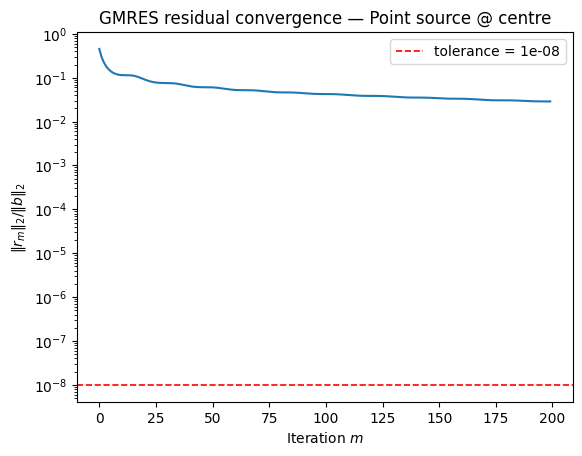

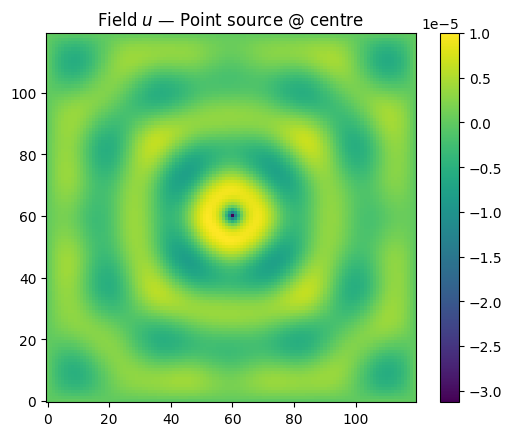

In [10]:
# PointSource supports: coordinates, "centre"/"center"/"middle", "origin"/"zero", or "random"
rhs_point = PointSource("centre", amplitude=1.0)

res_point = solve_case(rhs_point, label="Point source @ centre")


### Random

In [12]:
# Ensure complex operator dtype for complex-valued RHS
from src.operators import FiniteDifference, assemble_operator, BC
from src import GridSpec, GMRESOptions, gmres_solve
from src.visualisation import plot_residuals, plot_field

# Grid & operator
grid = GridSpec(dims=2, shape=(120, 120), lengths=(1.0, 1.0))
disc = FiniteDifference(bc=BC.DIRICHLET, dtype=np.complex128)
k = 30.0
A = assemble_operator(disc, grid, k)

# GMRES options
gmres_opts = GMRESOptions(tol=1e-8, restart=200, maxiter=200)

# Random point source (reproducible)
rand_point = RandomPointSource(amplitude_range=(0.8, 1.2),
                               phase_range=(0.0, 2*np.pi),
                               interior_only=True,
                               seed=123)

# Build RHS and solve
b = rand_point.build(grid)
res = gmres_solve(A, b, options=gmres_opts)

# Report + plots
print(f"Converged: {res.converged} | info: {res.info}")
if getattr(res, "residuals", None):
    print(f"Iterations: {len(res.residuals)}")
    print(f"Final relative residual: {res.residuals[-1]:.3e}")
    print("Last sample:", rand_point._last)

ax = plot_residuals(res, tol=gmres_opts.tol)
if ax is not None:
    ax.set_title("GMRES residuals — randomized point source")
    ax.set_xlabel("Iteration $m$")
    ax.set_ylabel(r"$\|r_m\|_2 / \|b\|_2$")

ax2 = plot_field(res.solution, grid.shape)
if ax2 is not None:
    ax2.set_title("Field $u$ — randomized point source")


TypeError: FiniteDifference.__init__() got an unexpected keyword argument 'bc'